# Evaluación del sistema — rendimiento, seguridad e integración
## Proyecto LACDA · Experiencia 3 (RA3)

**Asignatura:** ITY1101 — Gestión de Datos para IA, DUOC UC
**Documentos relacionados:** [`informe.ipynb`](informe.ipynb) (pipeline EP2) ·
[`estudio_features.ipynb`](estudio_features.ipynb) (selección de predictores)
**Repositorio:** https://github.com/Zzzhenda/Proyecto-LACDA

---

**Objetivo (RA3):** evaluar la efectividad del sistema de gestión de datos construido —
su rendimiento, seguridad y capacidad de integración — detectando limitaciones y proponiendo
mejoras. Mapeo con los indicadores de logro:

| Indicador | Qué pide | Dónde se desarrolla |
|---|---|---|
| IL 3.1 | Analizar el rendimiento en distintos escenarios | § 3 |
| IL 3.2 | Evaluar el nivel de seguridad | § 4 |
| IL 3.3 | Identificar capacidad de integración | § 5 |
| IL 3.4 | Detectar limitaciones o fallas | § 6 |
| IL 3.5 | Proponer mejoras técnicas/procedimentales | § 4, 6 y 7 |

> **Para ejecutar:** requiere el pipeline corrido (`docker compose up`), el modelo entrenado
> (`python scripts/train_model.py && python scripts/test_model.py`) y
> `pip install pandas scikit-learn matplotlib`.


## 1. El sistema evaluado

```
fuente CSV ──► pipeline DataOps (5 etapas, Docker) ──► PostgreSQL `loan_data`
                                                            │
                              ┌─────────────────────────────┼──────────────────┐
                              ▼                             ▼                  ▼
                    train_model.py / test_model.py    dashboard.py     (futuro: API REST,
                    (Random Forest + gate AUC)        (Streamlit)       herramientas BI)
```

Todo el flujo —datos y modelo— corre automatizado en GitHub Actions en cada push: las 5 etapas
del pipeline, el entrenamiento (leyendo desde Postgres) y la evaluación con **doble gate de
calidad**: el de datos (`validacion.py`, reglas del contrato) y el de modelo
(`test_model.py`, ROC-AUC ≥ 0.93).


## 2. Resultados del modelo (holdout de 9.000 filas nunca visto)

Random Forest (200 árboles, `class_weight="balanced"`) con el set de 12 predictores
seleccionado por evidencia en [`estudio_features.ipynb`](estudio_features.ipynb):


In [1]:
import json
import pickle
import re
import sys
import time
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

BASE = Path("..").resolve()
sys.path.insert(0, str(BASE / "scripts"))
DATA, RESULTS = BASE / "data", BASE / "results"
pd.set_option("display.max_columns", None)

met = json.loads((RESULTS / "metricas.json").read_text(encoding="utf-8"))
tabla_met = pd.DataFrame(
    [{k: v for k, v in met.items() if k != "classification_report"}], index=["holdout"]
).round(4)
tabla_met

,accuracy,precision,recall,f1_score,roc_auc
holdout,0.9238,0.8153,0.8495,0.832,0.975


El AUC en el holdout (0.975) es levemente **superior** a la estimación de validación cruzada
(0.9734): el modelo generaliza bien, sin señales de sobreajuste. Lectura de negocio de la
matriz de confusión:


In [2]:
from sklearn.metrics import confusion_matrix

X_test = pd.read_csv(DATA / "X_test.csv")
y_test = pd.read_csv(DATA / "y_test.csv").squeeze()
with open(BASE / "models" / "modelo_default.pkl", "rb") as f:
    model = pickle.load(f)

tn, fp, fn, tp = confusion_matrix(y_test, model.predict(X_test)).ravel()
print(f"De {tp + fn} defaults reales, el modelo detecta {tp} ({tp / (tp + fn):.1%}) "
      f"y se le escapan {fn}.")
print(f"De {tn + fp} préstamos pagados, marca {fp} como falsos positivos "
      f"({fp / (tn + fp):.1%} de clientes buenos rechazados).")

De 2000 defaults reales, el modelo detecta 1699 (85.0%) y se le escapan 301.
De 7000 préstamos pagados, marca 385 como falsos positivos (5.5% de clientes buenos rechazados).


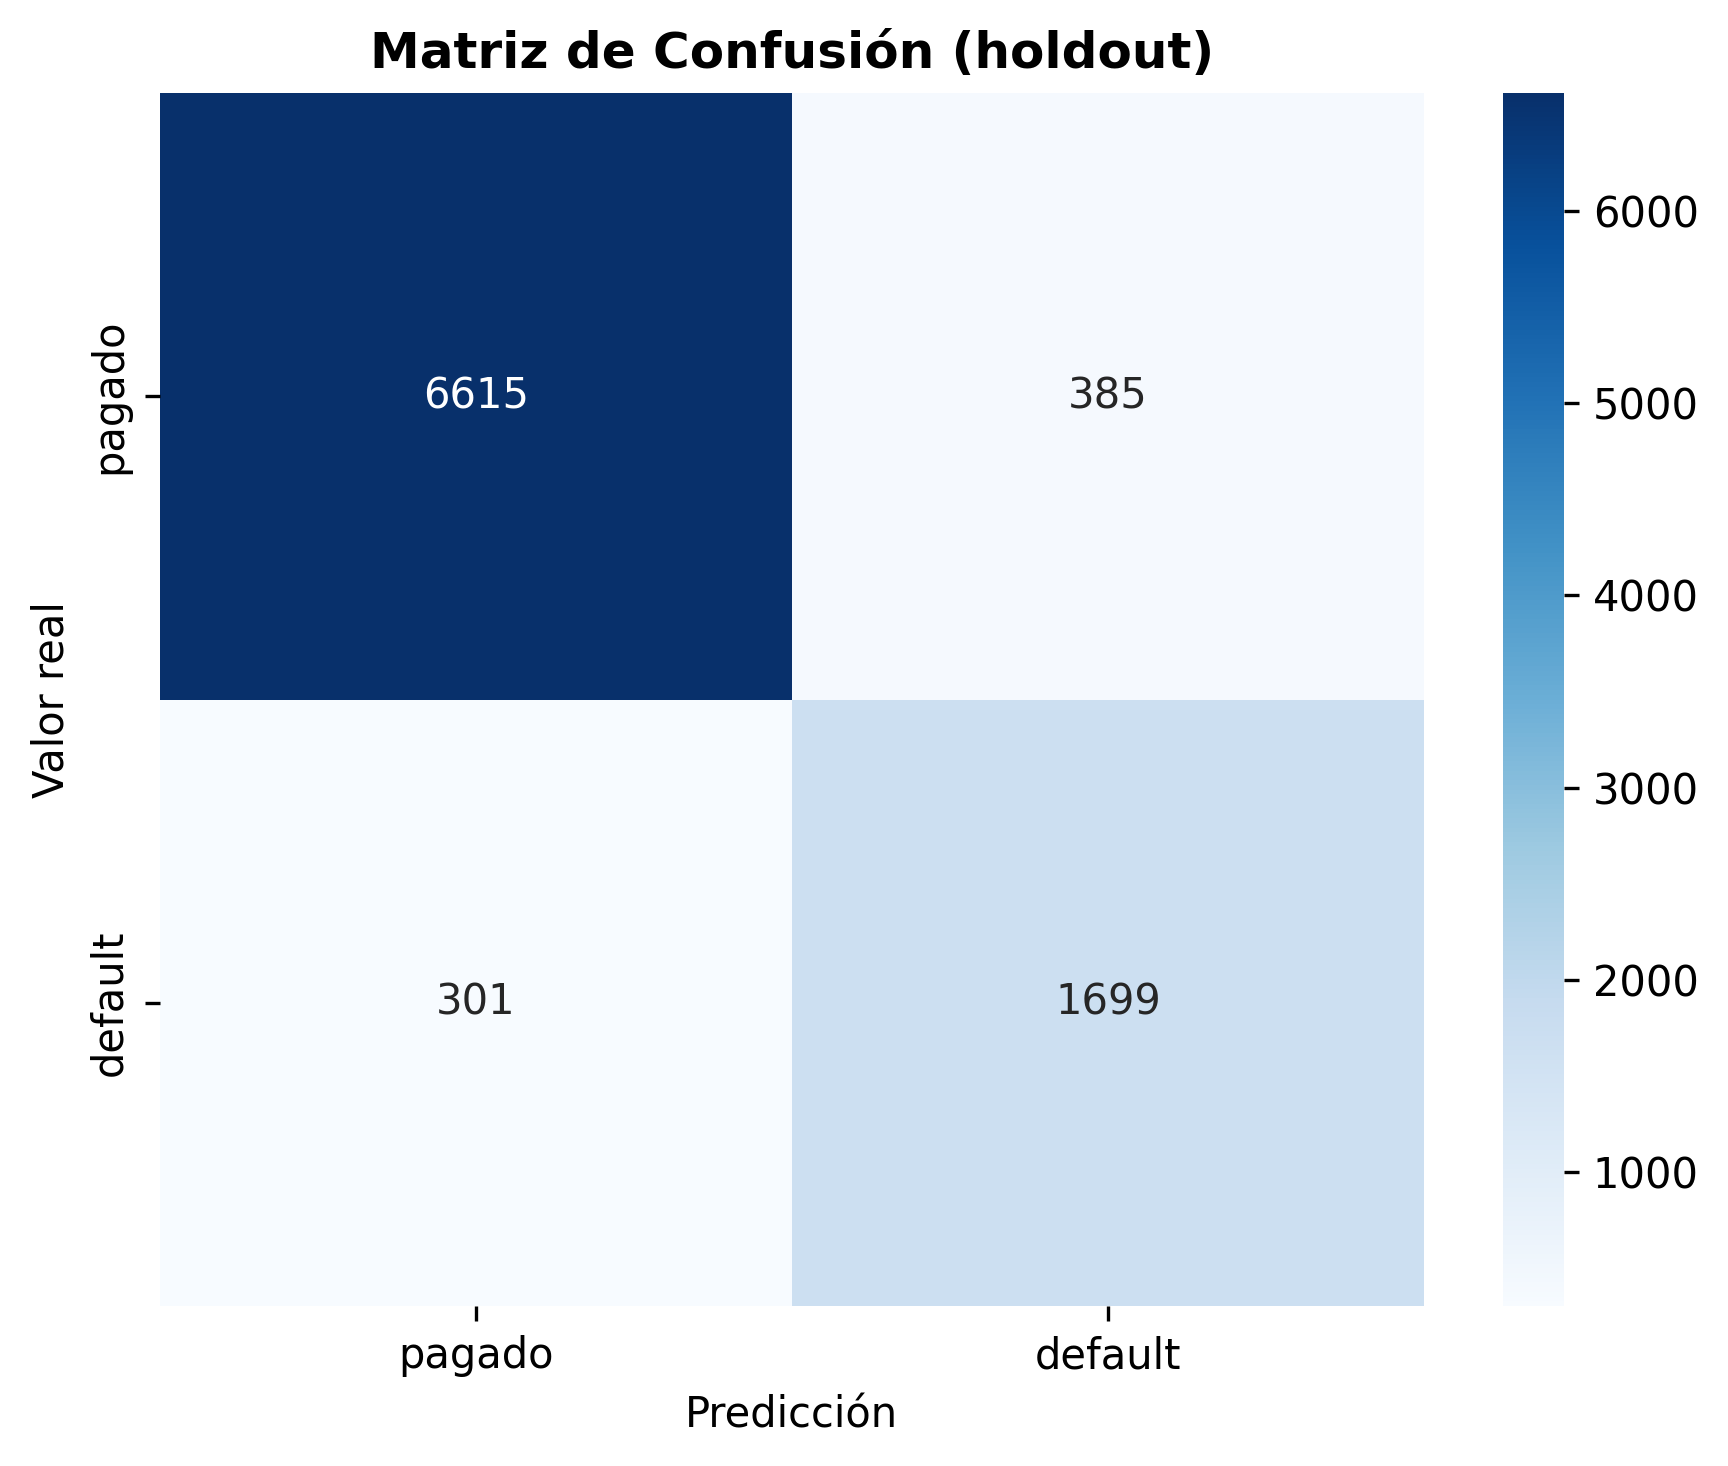

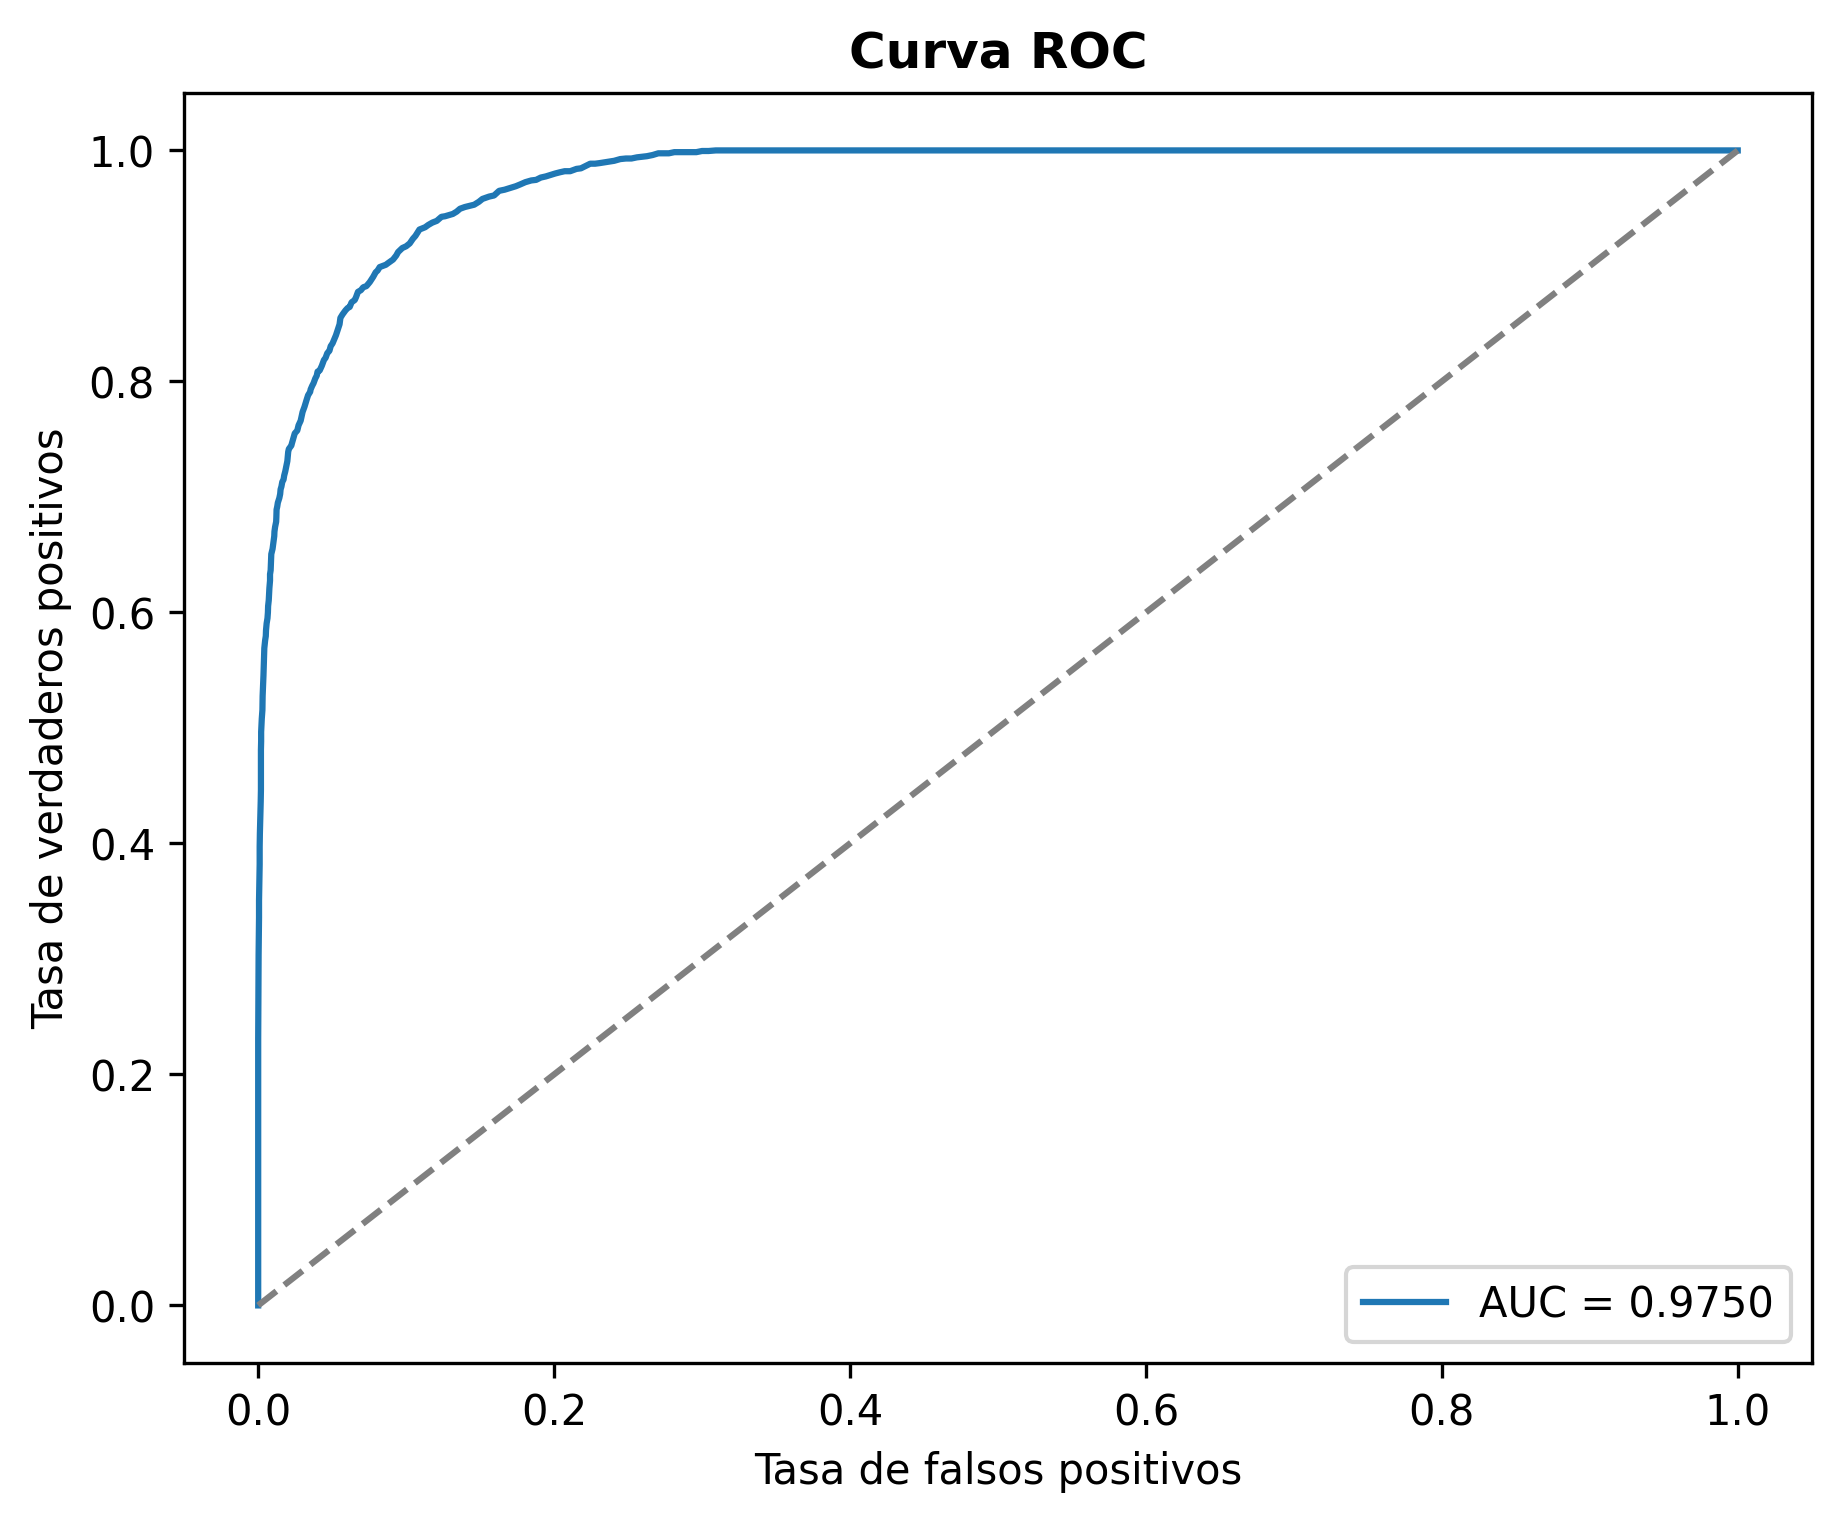

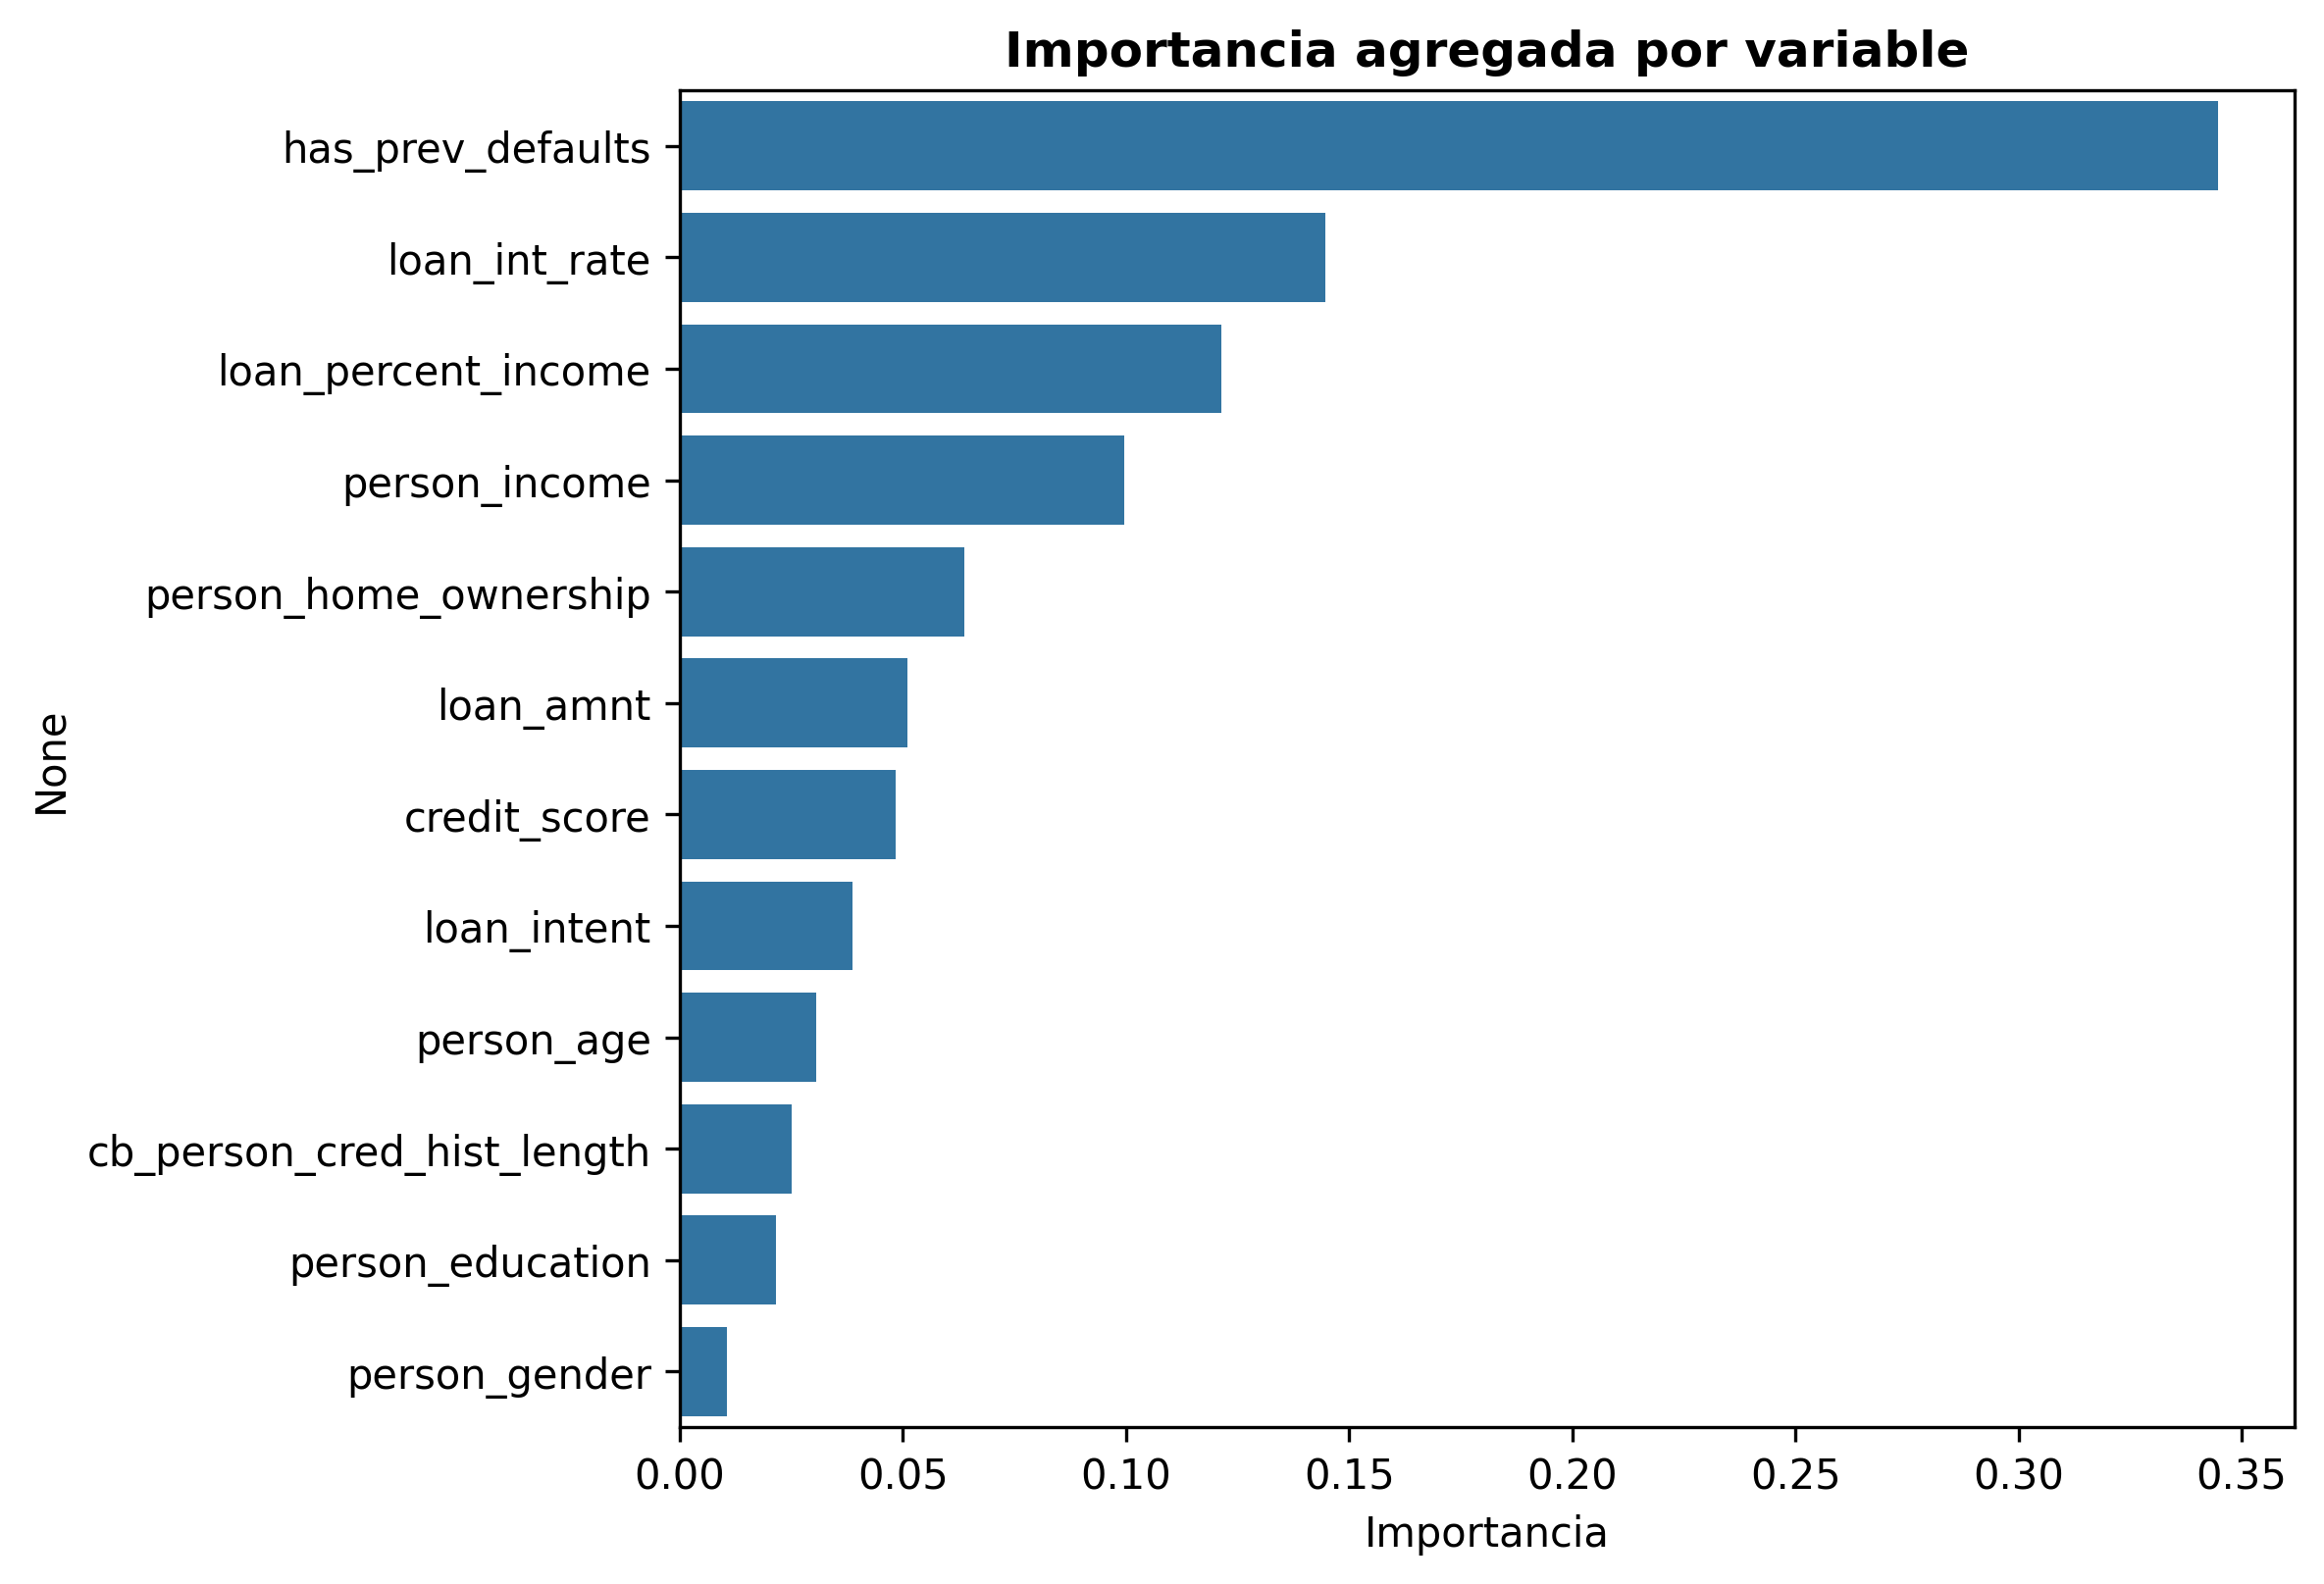

In [3]:
from IPython.display import Image, display

display(Image(str(RESULTS / "matriz_confusion.png"), width=430))
display(Image(str(RESULTS / "curva_roc.png"), width=470))
display(Image(str(RESULTS / "importancia_variables.png"), width=520))

La importancia de variables confirma el estudio de features: `has_prev_defaults` domina,
seguida por la tasa de interés y la carga del préstamo sobre el ingreso. Ninguna variable del
set es ruido (la menor, `person_gender`, aporta poco pero el estudio mostró que recortar más
variables degrada el AUC).


<a id="rendimiento"></a>
## 3. Rendimiento del pipeline (IL 3.1)

### 3.1 Tiempos reales por etapa

Medidos desde los logs de la última corrida completa en Docker
(`docs/evidencias_pipeline.log`); cada etapa registra timestamps de inicio y fin:


In [4]:
log_text = (BASE / "docs" / "evidencias_pipeline.log").read_text(encoding="utf-8")

# lineas tipo: "lacda_app  | [ingesta] 01:58:01 [INFO] ..."
marcas = {}
for etapa, hora in re.findall(r"\[(\w+)\] (\d{2}:\d{2}:\d{2})", log_text):
    marcas.setdefault(etapa, []).append(datetime.strptime(hora, "%H:%M:%S"))

dur = pd.Series(
    {e: (ts[-1] - ts[0]).total_seconds() for e, ts in marcas.items()}, name="segundos"
)
total = (max(t for ts in marcas.values() for t in ts)
         - min(t for ts in marcas.values() for t in ts)).total_seconds()
print(f"Tiempo total del pipeline (45.000 filas): {total:.0f} s")
dur.to_frame()

Tiempo total del pipeline (45.000 filas): 39 s


,segundos
ingesta,2.0
qualitycheck,1.0
limpieza,3.0
transformacion,3.0
validacion,16.0


La etapa dominante es **validación + carga** — y dentro de ella, la escritura a PostgreSQL
(`to_sql` de 45.000 filas por red local). Las etapas de procesamiento puro (limpieza,
transformación) toman ~2 s cada una. El entrenamiento del modelo agrega ~6 s
(lectura desde BD ~2 s + fit del Random Forest ~3 s).

### 3.2 Escalabilidad: ¿cómo se comporta con más volumen?

Para responder al escenario "¿y si la organización procesa 8 veces más solicitudes?",
se replica el dataset crudo (con ruido leve en `person_income` para no crear duplicados
artificiales) y se cronometran las operaciones núcleo de cada etapa:


[limpieza] 22:12:49 [INFO] Duplicados removidos: 0


[limpieza] 22:12:49 [INFO] Sin nulos que imputar.


[limpieza] 22:12:49 [INFO]   person_age: 7 valores fuera de [18, 100] -> clip


[limpieza] 22:12:49 [INFO] Rangos duros aplicados.


[limpieza] 22:12:49 [INFO] Reglas cruzadas (emp_exp, cred_hist_length) aplicadas.


...

[limpieza] 22:12:51 [INFO] Rangos duros aplicados.


[limpieza] 22:12:51 [INFO] Reglas cruzadas (emp_exp, cred_hist_length) aplicadas.


[limpieza] 22:12:51 [INFO] Dominios categoricos aplicados.


[limpieza] 22:12:51 [INFO] Winsorizacion 5% aplicada sobre: ['person_income', 'loan_amnt']


,limpieza (s),transformacion (s),validacion (s)
filas,,,
45000,0.12,0.01,0.04
90000,0.25,0.01,0.06
180000,0.44,0.01,0.10
360000,0.84,0.03,0.15


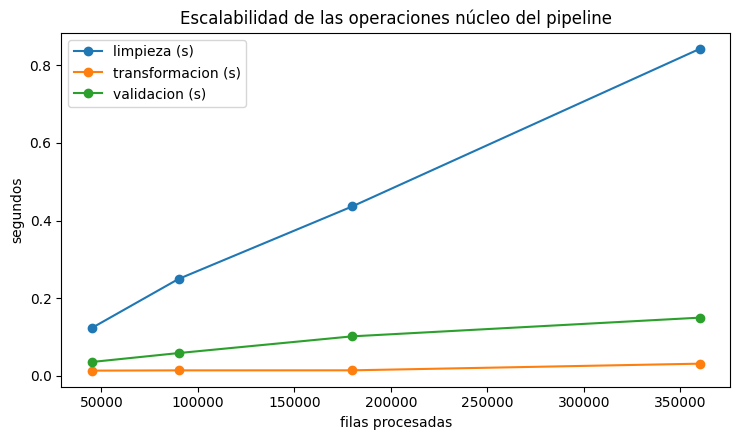

In [5]:
from limpieza import (aplicar_dominios, aplicar_rangos, aplicar_reglas_cruzadas,
                      imputar_nulos, remover_duplicados, winsorizar)
from validacion import validar_estructura, validar_features, validar_semantica

df_raw = pd.read_csv(DATA / "loan_data_raw.csv")
rng = np.random.default_rng(29)

filas = []
for factor in (1, 2, 4, 8):
    df_n = pd.concat([df_raw] * factor, ignore_index=True)
    df_n["person_income"] = (df_n["person_income"]
                             + rng.normal(0, 1, len(df_n)).round(2))

    t0 = time.perf_counter()
    df_c = winsorizar(aplicar_dominios(aplicar_reglas_cruzadas(
        aplicar_rangos(imputar_nulos(remover_duplicados(df_n))))))
    t_limpieza = time.perf_counter() - t0

    t0 = time.perf_counter()
    df_c["rate_x_pct_income"] = (df_c["loan_int_rate"] * df_c["loan_percent_income"]).round(4)
    df_c["loan_burden"] = ((df_c["loan_amnt"] * (1 + df_c["loan_int_rate"] / 100))
                           / df_c["person_income"].clip(lower=1)).round(4)
    df_c["has_prev_defaults"] = (df_c["previous_loan_defaults_on_file"] == "Yes").astype("int64")
    t_transform = time.perf_counter() - t0

    t0 = time.perf_counter()
    fallos = (validar_estructura(df_c) + validar_semantica(df_c) + validar_features(df_c))
    t_valida = time.perf_counter() - t0

    filas.append({"filas": len(df_n), "limpieza (s)": t_limpieza,
                  "transformacion (s)": t_transform, "validacion (s)": t_valida})

bench = pd.DataFrame(filas).set_index("filas")
ax = bench.plot(marker="o", figsize=(7.5, 4.5),
                title="Escalabilidad de las operaciones núcleo del pipeline")
ax.set_ylabel("segundos")
ax.set_xlabel("filas procesadas")
ax.figure.tight_layout()
bench.round(2)

**Lectura:** el crecimiento es **aproximadamente lineal** con el volumen — no hay operaciones
cuadráticas escondidas. A 360.000 filas (8×) el procesamiento sigue tomando segundos: el
cuello de botella real a gran escala será la **escritura a la base de datos** y la lectura de
CSV, no el procesamiento. De ahí las mejoras propuestas en § 7 (Parquet, `COPY` masivo).


<a id="seguridad"></a>
## 4. Auditoría de seguridad (IL 3.2)

Auditoría sobre código, contenedores, credenciales y datos. Cada hallazgo con su riesgo y
estado — los marcados ✅ se **corrigieron en esta fase** (las correcciones están en el repo):

| # | Hallazgo | Riesgo | Estado |
|---|---|---|---|
| 1 | Credenciales de la BD hardcodeadas en `docker-compose.yml` | Cualquiera con acceso al repo conoce las credenciales | ✅ **Corregido:** variables `${POSTGRES_*}` leídas desde `.env` (gitignored, con `.env.example` de plantilla); defaults solo para desarrollo local |
| 2 | El contenedor `app` corría como **root** | Si el proceso se compromete, el atacante es root dentro del contenedor | ✅ **Corregido:** la imagen define `USER appuser` (menor privilegio). En el compose local se vuelve a root explícitamente y documentado, porque el bind mount de Docker Desktop/Windows no acepta escrituras no-root (hallazgo verificado con prueba real — ver § 6) |
| 3 | Puerto 5432 publicado al host | La BD queda accesible desde la red local | ⚠️ **Aceptado en desarrollo** (lo usan notebook y dashboard); en producción: red interna de Docker sin `ports`, firewall y acceso solo vía aplicación |
| 4 | La aplicación usa el usuario dueño de la BD | Permisos excesivos: podría hacer `DROP TABLE` | 📋 **Propuesto:** rol `pipeline_rw` con permisos mínimos (`SELECT/INSERT/TRUNCATE` solo sobre `loan_data`) |
| 5 | Conexión a la BD sin TLS | Credenciales y datos viajan en claro | ⚠️ Aceptado en red local de Docker; en nube: `sslmode=require` |
| 6 | Credenciales en texto plano en `ci.yml` | Visibles en el repositorio | ⚠️ Aceptado: es una BD **efímera** del job de CI con datos públicos; con datos reales → GitHub Secrets |
| 7 | Sin escaneo de vulnerabilidades de imagen/dependencias | CVEs sin detectar en pandas/Postgres/base image | 📋 **Propuesto:** Dependabot + job de Trivy en CI |
| 8 | Privacidad de los datos | — | 🟢 El dataset no contiene identificadores directos (nombres, RUT, direcciones). `person_gender`/`person_age` son cuasi-identificadores: si se integrara con datos reales de clientes, aplicar seudonimización y evaluar sesgo del modelo por género (ética/regulación bancaria) |

**Nivel de seguridad global:** adecuado para un entorno académico/desarrollo, con los dos
riesgos principales (credenciales y root) ya corregidos. La brecha hacia producción está
identificada y priorizada en § 7.


<a id="integracion"></a>
## 5. Capacidad de integración (IL 3.3)

El diseño "PostgreSQL como destino único" convierte la BD en el **punto de integración** del
sistema con otras plataformas organizacionales:

| Integración | Estado | Cómo |
|---|---|---|
| Capa de datos → capa ML | ✅ Operativa | `train_model.py` lee directamente la tabla `loan_data`; si la BD no está disponible, hace *fallback* automático al CSV transformado (tolerancia a fallos verificada) |
| Pipeline → CI/CD | ✅ Operativa | GitHub Actions corre datos + modelo en cada push, con artifacts descargables (CSVs procesados, métricas, gráficos) |
| Sistema → dashboard | ✅ Operativa | `dashboard.py` (Streamlit) integra en una vista: estado de la tabla (consulta en vivo), KPI de calidad con alertas y métricas del modelo — `streamlit run dashboard.py` |
| BD → herramientas BI | 🟢 Disponible | Cualquier herramienta organizacional (Power BI, Metabase, Grafana) se conecta a PostgreSQL con un connection string estándar; no requiere desarrollo |
| Modelo → sistemas externos | 📋 Próximo paso | El modelo serializado (`models/modelo_default.pkl`) está listo para servirse tras una API REST (FastAPI) y entregar scoring en línea a los sistemas de crédito |

La pieza que materializa la integración para la demo es el **dashboard**: una sola pantalla
que consulta la BD en vivo, recalcula el KPI de calidad y muestra las métricas del modelo.


<a id="fallas"></a>
## 6. Limitaciones y fallas detectadas (IL 3.4)

Todas son fallas **reales** encontradas (y tratadas) durante el desarrollo y esta evaluación:

| Falla / limitación | Cómo se detectó | Tratamiento |
|---|---|---|
| **OneDrive eliminó los CSVs intermedios** del directorio de trabajo entre sesiones | `FileNotFoundError` al iniciar el estudio de features | El diseño re-ejecutable salvó la situación: cada etapa se re-corre por separado y los archivos se regeneraron en segundos. *Mejora propuesta:* sacar el repo de una carpeta sincronizada o usar staging en volumen Docker |
| **Features derivadas redundantes** (`loan_burden` |corr| 0.978 con `loan_percent_income`) | Auditoría con el `CorrelationFilter` del curso + validación cruzada | Excluidas del modelo (set S3); se mantienen en la capa de datos donde sí tienen uso (BI, modelos lineales) |
| **Bug en el material de referencia del curso**: `test_model.py` leía `X_test.csv`/`y_test.csv` que `train_model.py` nunca guardaba | Lectura crítica del código antes de adaptarlo | Corregido: el train guarda el holdout exacto y el test lo consume — evaluación reproducible |
| **Usuario no-root no puede escribir en el bind mount** (Docker Desktop/Windows) | `PermissionError` en corrida de verificación tras endurecer el Dockerfile | Imagen no-root por defecto + override explícito y documentado solo en el compose de desarrollo |
| **El KPI de calidad no persiste histórico** — cada corrida imprime el score y se pierde | Análisis de observabilidad de esta evaluación | Propuesto en § 7: tabla `quality_log` (fecha, score, dimensiones) para detectar degradación de la fuente en el tiempo |
| **Esquema aplicado solo al crear el volumen** (`init.sql` no migra cambios) | Detectado al rediseñar el esquema (hubo que recrear el volumen) | Documentado; propuesto: herramienta de migraciones (Alembic) si el esquema evoluciona |


<a id="mejoras"></a>
## 7. Mejoras propuestas (IL 3.5)

Priorizadas por impacto vs. esfuerzo:

| Prioridad | Mejora | Tipo | Impacto | Esfuerzo |
|---|---|---|---|---|
| 🔴 Alta | **API REST (FastAPI)** que sirva el modelo para scoring en línea | Técnica | Integración real con los sistemas de crédito de la organización | Medio |
| 🔴 Alta | **Persistir el KPI de calidad** por corrida (tabla `quality_log`) y alertar en CI si el score cae respecto de la corrida anterior | Técnica | Observabilidad histórica: detecta degradación de la fuente automáticamente | Bajo |
| 🟡 Media | Rol de BD de **menor privilegio** + TLS en la conexión | Seguridad | Cierra los hallazgos 4 y 5 de la auditoría | Bajo |
| 🟡 Media | **Staging en Parquet** y carga con `COPY` en lugar de INSERT | Rendimiento | Sostiene volúmenes 100× (el cuello identificado en § 3) | Bajo |
| 🟡 Media | **Tuning de hiperparámetros** (GridSearchCV) y calibración del umbral de decisión según el costo de negocio (un default no detectado cuesta más que un buen cliente rechazado) | Técnica | Más recall al costo elegido por el negocio | Medio |
| 🟢 Baja | Orquestador (**Airflow**) en reemplazo del encadenado `&&` | Procedimental | Programación, reintentos y monitoreo por etapa a escala | Alto |
| 🟢 Baja | Dependabot + escaneo Trivy en CI | Seguridad | Vulnerabilidades detectadas de forma continua | Bajo |


## 8. Conclusiones

* **Efectividad:** el sistema convierte 45.000 solicitudes crudas en una tabla validada y un
  modelo con **ROC-AUC 0.975** en holdout, todo automatizado y con doble gate de calidad
  (datos y modelo). La evaluación confirma que la arquitectura simple elegida (5 etapas,
  tabla única, contrato centralizado) es también **medible, auditable y extensible**.
* **Rendimiento (IL 3.1):** procesamiento lineal con el volumen; a 8× el dataset las
  operaciones núcleo siguen en segundos. El cuello identificado (escritura a BD) tiene
  mitigación propuesta de bajo esfuerzo.
* **Seguridad (IL 3.2):** los dos riesgos principales se corrigieron en esta fase
  (credenciales a `.env`, imagen no-root); el resto está identificado, aceptado con
  justificación o priorizado.
* **Integración (IL 3.3):** PostgreSQL como hub permite BI estándar; la capa ML ya consume la
  BD con fallback; el dashboard une las tres capas en una vista.
* **Fallas (IL 3.4):** seis limitaciones reales detectadas, cuatro resueltas durante la fase
  y dos convertidas en mejoras priorizadas.
* **Mejoras (IL 3.5):** roadmap priorizado de 7 mejoras; las dos de prioridad alta (API de
  scoring y KPI histórico) son los siguientes pasos naturales del proyecto.
